<a href="https://colab.research.google.com/github/riidhooo12-oss/Visi-Komputer-Semester-3/blob/main/Jobsheet_02_Klasifikasi_Gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jobsheet 02: Klasifikasi Gambar
**Mata Kuliah:** Pemrograman Berorientasi Objek (432-242-206)
**Dosen:** Ir. Prayitno, S.ST., M.T., Ph.D.
**Nama:** Ridho Arsyil Hakim
**NIM:** 4.33.25.1.23

Notebook ini berisi seluruh kode Praktikum D1–D6 beserta jawaban **Tugas Kecil** di tiap bagian.
Jalankan sel secara berurutan dari atas ke bawah di Google Colab.

## Praktikum D1 – Memulai Klasifikasi Gambar dengan Dataset Sederhana

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Shape x_train:", x_train.shape)
print("Shape y_train:", y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape x_train: (60000, 28, 28)
Shape y_train: (60000,)


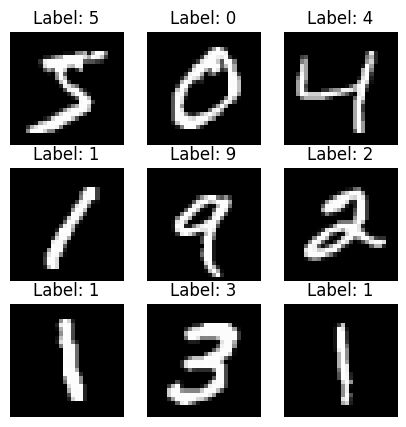

In [8]:
# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

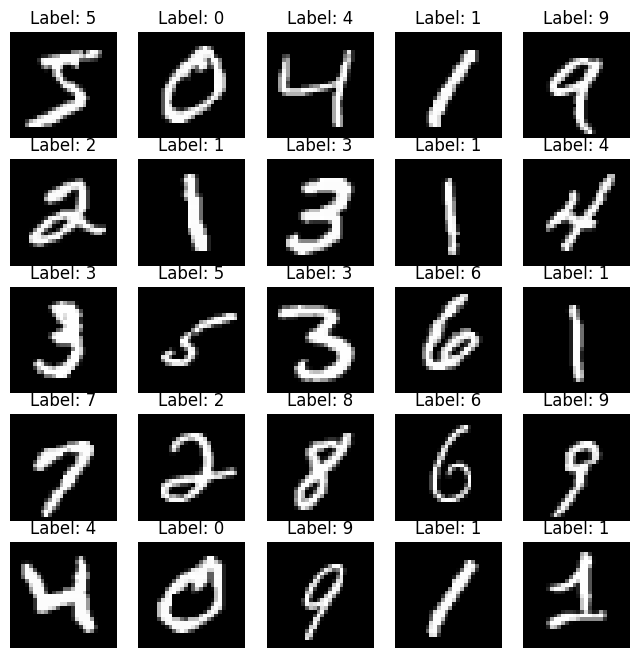

In [9]:
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

## Praktikum D2 – Klasifikasi Gambar dengan Model Machine Learning Tradisional (SVM)

In [10]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM dengan kernel linear
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000])  # gunakan subset karena SVM berat

y_pred = clf.predict(x_test_flat)
print("Akurasi (kernel linear):", accuracy_score(y_test, y_pred))

Akurasi (kernel linear): 0.9101


In [11]:
# Percobaan dengan kernel rbf
clf_rbf = svm.SVC(kernel='rbf', gamma='scale')
clf_rbf.fit(x_train_flat[:5000], y_train[:5000])

y_pred_rbf = clf_rbf.predict(x_test_flat)
print("Akurasi (kernel rbf):", accuracy_score(y_test, y_pred_rbf))

Akurasi (kernel rbf): 0.9513


## Praktikum D3 – Membangun CNN Sederhana

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.9466 - loss: 0.1842 - val_accuracy: 0.9823 - val_loss: 0.0686
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9812 - loss: 0.0606 - val_accuracy: 0.9860 - val_loss: 0.0538
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.9876 - loss: 0.0398 - val_accuracy: 0.9857 - val_loss: 0.0563
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9911 - loss: 0.0281 - val_accuracy: 0.9880 - val_loss: 0.0458
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9937 - loss: 0.0202 - val_accuracy: 0.9883 - val_loss: 0.0489


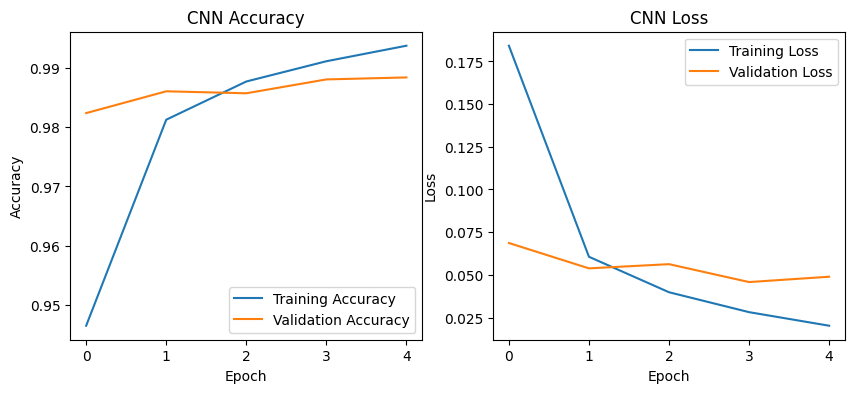

In [13]:
# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [14]:
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),   # lapisan Conv2D tambahan
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.9554 - loss: 0.1498 - val_accuracy: 0.9860 - val_loss: 0.0488
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9837 - loss: 0.0518 - val_accuracy: 0.9855 - val_loss: 0.0416
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9887 - loss: 0.0356 - val_accuracy: 0.9848 - val_loss: 0.0514
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9919 - loss: 0.0264 - val_accuracy: 0.9872 - val_loss: 0.0470
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - accuracy: 0.9936 - loss: 0.0197 - val_accuracy: 0.9892 - val_loss: 0.0384


## Praktikum D4 – Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

In [15]:
from tensorflow.keras.datasets import cifar10

(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()
x_train_c, x_test_c = x_train_c/255.0, x_test_c/255.0

model3 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model3.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history3 = model3.fit(x_train_c, y_train_c, epochs=10, validation_split=0.1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1715s 10us/step
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 43ms/step - accuracy: 0.4512 - loss: 1.5221 - val_accuracy: 0.5154 - val_loss: 1.3746
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.5908 - loss: 1.1681 - val_accuracy: 0.6340 - val_loss: 1.0732
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 40ms/step - accuracy: 0.6374 - loss: 1.0368 - val_accuracy: 0.6406 - val_loss: 1.0344
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.6689 - loss: 0.9539 - val_accuracy: 0.6542 - val_loss: 1.0034
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - accuracy: 0.6927 - loss: 0.8856 - val_accuracy: 0.6912 - val_loss: 0.9011
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.7110 - loss: 0.8324 - val_accuracy: 0.6848 - val_loss: 0.9235
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 43ms/step - accuracy: 0.7259 - loss: 0.7868 - val_accuracy: 0.6862 - val_loss: 0.9274
Epoch 8/10
1407/140

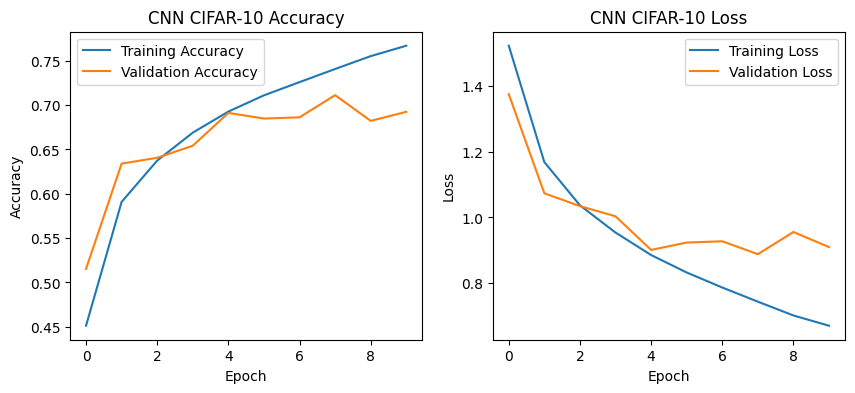

In [16]:
# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history3.history['accuracy'], label='Training Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [17]:
model4 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),                     # lapisan Dropout ditambahkan
    layers.Dense(10, activation='softmax')
])

model4.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history4 = model4.fit(x_train_c, y_train_c, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 40ms/step - accuracy: 0.3338 - loss: 1.7915 - val_accuracy: 0.4722 - val_loss: 1.4764
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.4454 - loss: 1.5108 - val_accuracy: 0.5412 - val_loss: 1.2507
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accuracy: 0.5048 - loss: 1.3799 - val_accuracy: 0.6024 - val_loss: 1.1731
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.5365 - loss: 1.2851 - val_accuracy: 0.6254 - val_loss: 1.0791
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.5646 - loss: 1.2182 - val_accuracy: 0.6364 - val_loss: 1.0554
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.5867 - loss: 1.1593 - val_accuracy: 0.6664 - val_loss: 0.9717
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.6044 - loss: 1.1206 - val_accuracy: 0.6632 - val_loss: 0.9634
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.6146 -

## Praktikum D5 – Transfer Learning dengan Model Pra-Latih (VGG16)

In [18]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False

model5 = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model5.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history5 = model5.fit(x_train_c, y_train_c, epochs=5, validation_split=0.1)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 605s 428ms/step - accuracy: 0.5212 - loss: 1.3789 - val_accuracy: 0.5528 - val_loss: 1.2470
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 602s 428ms/step - accuracy: 0.5838 - loss: 1.1971 - val_accuracy: 0.5950 - val_loss: 1.1546
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 603s 429ms/step - accuracy: 0.6022 - loss: 1.1373 - val_accuracy: 0.6058 - val_loss: 1.1450
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 601s 427ms/step - accuracy: 0.6158 - loss: 1.0985 - val_accuracy: 0.6034 - val_loss: 1.1332
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 646s 444ms/step - accuracy: 0.6269 - loss: 1.0645 - val_accuracy: 0.5990 - val_loss: 1.1265


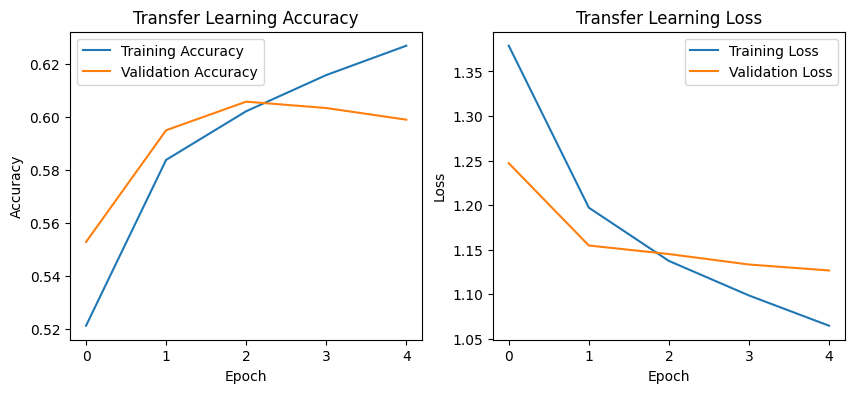

In [19]:
# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history5.history['accuracy'], label='Training Accuracy')
plt.plot(history5.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history5.history['loss'], label='Training Loss')
plt.plot(history5.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [20]:
base_model.trainable = True
for layer in base_model.layers[:-2]:
    layer.trainable = False   # bekukan semua kecuali 2 lapisan terakhir

model5.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history_finetune = model5.fit(x_train_c, y_train_c, epochs=5, validation_split=0.1)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 692s 491ms/step - accuracy: 0.6626 - loss: 0.9643 - val_accuracy: 0.6434 - val_loss: 1.0265
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 690s 491ms/step - accuracy: 0.6918 - loss: 0.8890 - val_accuracy: 0.6526 - val_loss: 0.9977
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 693s 493ms/step - accuracy: 0.7073 - loss: 0.8362 - val_accuracy: 0.6640 - val_loss: 0.9870
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 669s 476ms/step - accuracy: 0.7254 - loss: 0.7935 - val_accuracy: 0.6646 - val_loss: 0.9740
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 681s 475ms/step - accuracy: 0.7377 - loss: 0.7549 - val_accuracy: 0.6716 - val_loss: 0.9629


## Praktikum D6 – Evaluasi dengan Confusion Matrix dan Metrik Lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
              precision    recall  f1-score   support

           0       0.69      0.80      0.74      1000
           1       0.79      0.81      0.80      1000
           2       0.65      0.53      0.58      1000
           3       0.45      0.55      0.49      1000
           4       0.64      0.63      0.64      1000
           5       0.52      0.65      0.58      1000
           6       0.85      0.68      0.76      1000
           7       0.79      0.69      0.73      1000
           8       0.79      0.81      0.80      1000
           9       0.84      0.70      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.70      0.68      0.69     10000
weighted avg       0.70      0.68      0.69     10000



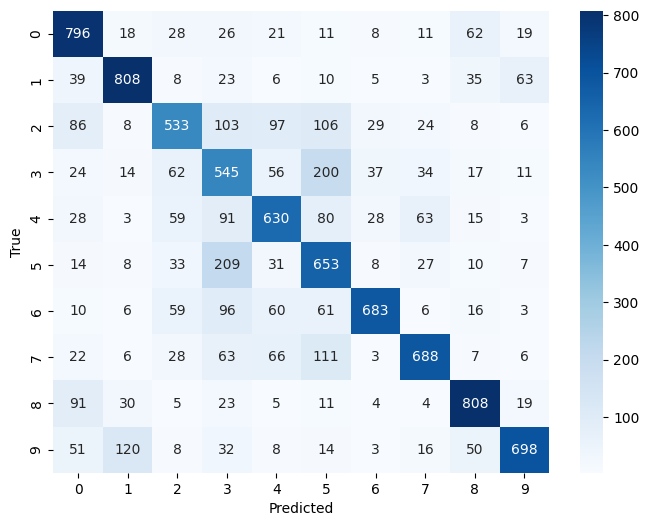

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_c = model3.predict(x_test_c).argmax(axis=1)
print(classification_report(y_test_c, y_pred_c))

cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Penugasan 3 – Klasifikasi Tulisan Angka Sendiri

In [22]:
# ===== 2) Utilitas Preprocess agar mirip MNIST (28x28, putih-di-atas-hitam) =====
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
    """
    Langkah:
    - Konversi ke grayscale
    - Auto-contrast
    - (Opsional) invert bila latar terang
    - Crop ke bounding box digit
    - Resize mempertahankan rasio ke (20x20), lalu pad ke (28x28)
    - Normalisasi ke [0,1] dan tambah axis channel
    """
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.uint8)

    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    thr = np.mean(arr) * 0.8
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1+1, y1+1))

    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w)//2, (28 - h)//2))

    arr = np.array(canvas).astype('float32') / 255.0
    arr = arr[..., None]
    return canvas, arr

### (Pilihan A) Prediksi dengan CNN dari D3

Saving WIN_20260916_20_13_27_Pro.jpg to WIN_20260916_20_13_27_Pro.jpg


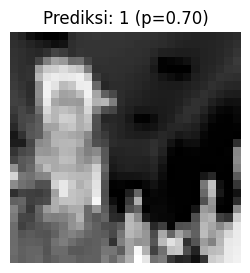

Rekap Prediksi (CNN):
- WIN_20260916_20_13_27_Pro.jpg -> 1 (p=0.698)


In [29]:
from google.colab import files
uploaded = files.upload()

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
    img = img_pil.convert('L')
    img = ImageOps.invert(img)
    img = img.resize((28, 28))
    x = np.array(img).astype('float32') / 255.0
    return img, x

results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x = preprocess_to_mnist_28x28(img_pil)
    x_batch = np.expand_dims(x, axis=0)

    probs = model.predict(x_batch, verbose=0)[0]
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))
    results.append((fname, pred, conf))

    plt.figure(figsize=(3,3))
    plt.imshow(disp, cmap='gray')
    plt.title(f"Prediksi: {pred} (p={conf:.2f})")
    plt.axis('off')
    plt.show()

print("Rekap Prediksi (CNN):")
for r in results:
    print(f"- {r[0]} -> {r[1]} (p={r[2]:.3f})")

### (Pilihan B) Prediksi dengan SVM dari D2